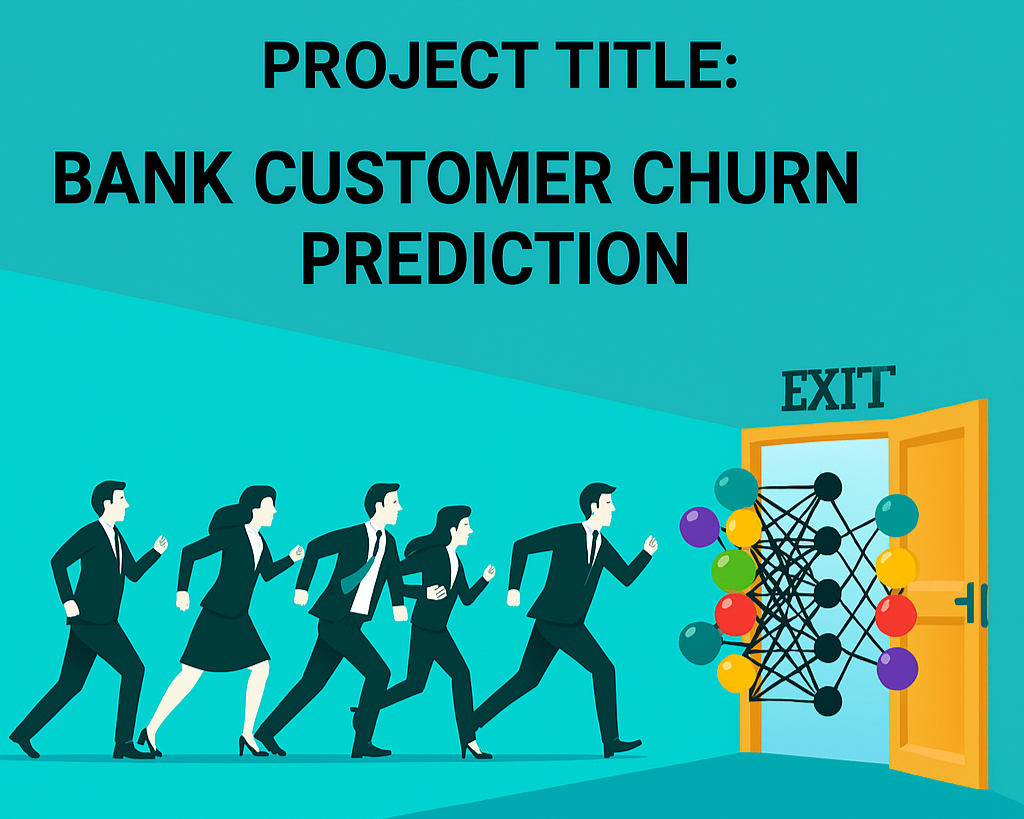

#<font color="skyblue">**📝Problem Statement:🚀**</font>


---


  *As we know, it is much more expensive to sign in a new client than keeping an existing one. It is advantageous for banks to know what leads a client towards the decision to leave the company.*



---





#<font color= "skyblue">**🎯Objective:**</font>


---


*The goal of this project is to develop a machine learning model to predict whether a customer will churn (i.e., leave the bank) or stay based on their demographic and financial features and use this model to identify high-risk customers (those most likely to churn) and take proactive measures to retain them, thereby improving customer retention and lowering the amount of money the bank spends to get new customers.*




---



#🔗<font color= "lightblue">**Dataset link:**</font>


 https://github.com/Gayathrianalyst/Machine-Learning-Project-Raw-Data/tree/main


---




#**📊 Dataset overview:**


---
| **Column**            |               **Description**                                                                                                  |
|:----------------------|:----------------------------------------------------------------------------------------------------------------------|
|      **RowNumber**                  | corresponds to the record (row) number.                            |
| **CustomerId**                 | contains unique values .        |
| **Surname**                   | the surname of a customer.       |
|**CreditScore**                 |   credit score of the customer. |
|**Geography**                   |    customer’s location.         |
|**Gender**                      |  gender of the customer.        |
|**Age**                         |   Age of the customer.          |
|**Tenure**                      |   refers to the number of years that the customer has been a client of the bank.                            |
|**Balance**                     |Account balance of the customer. |
|**NumOfProducts**                |refers to the number of products that a customer has purchased through the bank.                           |
|**HasCrCard**                    |denotes whether or not a customer has a credit card.            |
|**IsActiveMember**               |denotes whether a customer is active or not.                                |
|**EstimatedSalary**                   |The estimated salary is an approximation of how much the customer earns annually or monthly.               |
|**Exited**                      |whether or not the customer left the bank.           |
|**Satisfaction Score**              |Score provided by the customer for their complaint resolution.  |
|**Card Type**                        | type of card hold by the customer.  |
|**Points Earned** | the points earned by the customer for using credit.    |

---

# **✅Let's Understand the data**



---



##🗄️**Importing libraries**

In [152]:
# import the crucial libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# enable warnings
import warnings
warnings.filterwarnings('ignore')

##**📥 Loading the Dataset 🗂️**

In [153]:
# loading the dataset using pandas library
churn_df = pd.read_csv('Customer_Churn_Records_data.csv')

##**🔍Initial Exploratory Data Analysis (EDA)📈**

In [154]:
# first 5 rows of the dataset
churn_df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619.0,france,FEMALE,42.0,2,0.00,1,Yes,Yes,101348.88,Yess,Yes,2,diamond,464
1,2,15647311,Hill,608.0,spain,FEMALE,41.0,1,83807.86,1,No,Yes,112542.58,N0,Yes,3,diamond,456
2,3,15619304,Onio,502.0,france,FEMALE,42.0,8,159660.80,3,Yes,No,113931.57,Yess,Yes,3,diamond,377
3,4,15701354,Boni,699.0,france,FEMALE,39.0,1,0.00,2,No,No,93826.63,N0,No,5,Gold,350
4,5,15737888,Mitchell,850.0,spain,FEMALE,43.0,2,125510.82,1,Yes,Yes,79084.10,N0,No,5,Gold,425


In [155]:
# last 5 rows of the dataset
churn_df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
10195,3460,15754919,Nwebube,773.0,france,FEMALE,40.0,10,0.00,2,No,Yes,355.00,N0,No,3,Platinum,826
10196,2462,15592765,Marks,637.0,france,M,40.0,8,125470.81,1,Yes,Yes,174536.17,N0,No,4,Platinum,658
10197,5400,15628904,Bowen,733.0,spain,M,35.0,8,102918.38,1,Yes,Yes,45959.86,N0,No,5,Platinum,899
10198,8938,15737404,Kesteven,731.0,france,M,31.0,1,132512.26,1,Yes,Yes,185466.85,N0,No,3,SILVR,960
10199,808,15798906,Cox,628.0,france,M,69.0,5,0.00,2,Yes,Yes,181964.60,N0,No,3,diamond,348


In [156]:
# No of rows and features of the dataset
churn_df.shape
print(f"This dataset contain {churn_df.shape[0]} Rows and {churn_df.shape[1]} Features")

This dataset contain 10200 Rows and 18 Features


In [157]:
# Exploring detailed over view of the dataset
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10200 non-null  int64  
 1   CustomerId          10200 non-null  int64  
 2   Surname             10200 non-null  object 
 3   CreditScore         10117 non-null  float64
 4   Geography           10200 non-null  object 
 5   Gender              10200 non-null  object 
 6   Age                 10133 non-null  float64
 7   Tenure              10200 non-null  int64  
 8   Balance             10103 non-null  float64
 9   NumOfProducts       10200 non-null  int64  
 10  HasCrCard           10200 non-null  object 
 11  IsActiveMember      10200 non-null  object 
 12  EstimatedSalary     10158 non-null  float64
 13  Exited              10200 non-null  object 
 14  Complain            10200 non-null  object 
 15  Satisfaction Score  10200 non-null  int64  
 16  Card

In [158]:
# Finding the no of null values
churn_df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,83
Geography,0
Gender,0
Age,67
Tenure,0
Balance,97
NumOfProducts,0


##🧐**Insights:🔍**
📍 This dataset has missing values.

In [159]:
# exporing column names of the dataset
churn_df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'Satisfaction Score', 'Card Type', 'Point Earned'],
      dtype='object')

In [160]:
# copying dataset
churn_copy = churn_df.copy()
churn_copy.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619.0,france,FEMALE,42.0,2,0.00,1,Yes,Yes,101348.88,Yess,Yes,2,diamond,464
1,2,15647311,Hill,608.0,spain,FEMALE,41.0,1,83807.86,1,No,Yes,112542.58,N0,Yes,3,diamond,456
2,3,15619304,Onio,502.0,france,FEMALE,42.0,8,159660.80,3,Yes,No,113931.57,Yess,Yes,3,diamond,377
3,4,15701354,Boni,699.0,france,FEMALE,39.0,1,0.00,2,No,No,93826.63,N0,No,5,Gold,350
4,5,15737888,Mitchell,850.0,spain,FEMALE,43.0,2,125510.82,1,Yes,Yes,79084.10,N0,No,5,Gold,425


##⭕ **Dropping unneccessary columns from the dataset since it is no use for churn prediction**


In [161]:
# Removing "Surname" column since it is also not useful for churn prediction
churn_copy.drop(['Surname'], axis=1, inplace=True)

# Removing "customerId" column because it has no predictive power since it's randomly assigned.
churn_copy.drop(['CustomerId'], axis=1, inplace=True)
churn_copy.head()

,RowNumber,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,619.0,france,FEMALE,42.0,2,0.00,1,Yes,Yes,101348.88,Yess,Yes,2,diamond,464
1,2,608.0,spain,FEMALE,41.0,1,83807.86,1,No,Yes,112542.58,N0,Yes,3,diamond,456
2,3,502.0,france,FEMALE,42.0,8,159660.80,3,Yes,No,113931.57,Yess,Yes,3,diamond,377
3,4,699.0,france,FEMALE,39.0,1,0.00,2,No,No,93826.63,N0,No,5,Gold,350
4,5,850.0,spain,FEMALE,43.0,2,125510.82,1,Yes,Yes,79084.10,N0,No,5,Gold,425


##⭕ **Handling duplicates**



---



In [162]:
# finding duplicates using function
churn_copy.duplicated().sum()

np.int64(197)

In [163]:
# Removing duplicates
churn_copy.drop_duplicates(inplace=True)
churn_copy.duplicated().sum()

np.int64(0)

##⭕ **Exploring Numerical Features through statistical summary.**

In [164]:
# Exploring Numerical features distribution using Desciptive statistic
churn_copy.describe()

,RowNumber,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Satisfaction Score
count,10003.000000,9923.000000,9937.000000,10003.000000,9906.000000,10003.000000,9961.000000,10003.000000
mean,5000.385184,632.329386,51.568079,5.013396,70959.660717,1.530241,97286.806582,3.013996
std,2886.510577,146.697099,82.151108,2.891980,63183.038274,0.581629,58992.707057,1.405919
min,1.000000,19.000000,18.000000,0.000000,0.000000,1.000000,11.580000,1.000000
25%,2501.500000,571.000000,32.000000,3.000000,0.000000,1.000000,46884.100000,2.000000
50%,5000.000000,648.000000,38.000000,5.000000,89981.700000,1.000000,96862.560000,3.000000
75%,7499.500000,718.000000,45.000000,7.000000,125374.540000,2.000000,147693.920000,4.000000
max,10000.000000,1275.000000,799.000000,10.000000,250898.090000,4.000000,199992.480000,5.000000


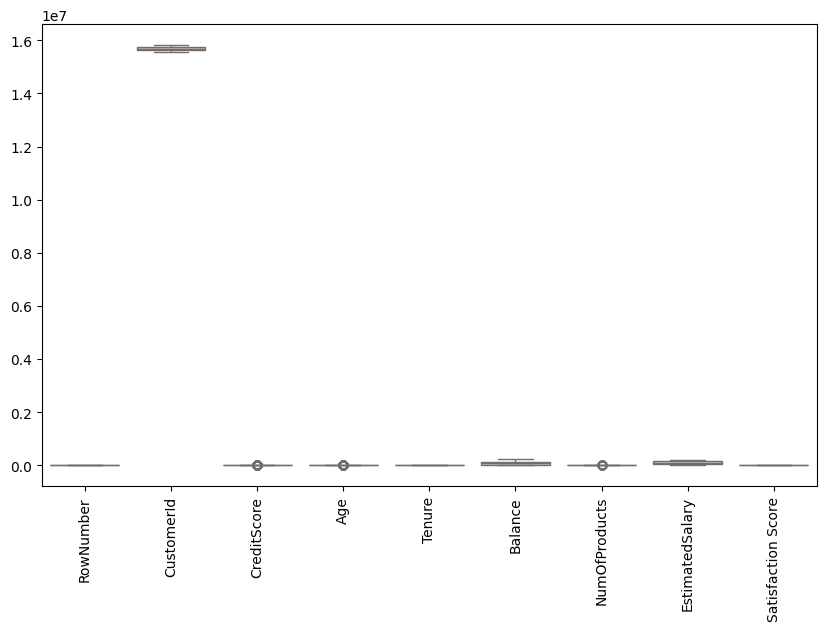

In [165]:
# Finding outliers using boxplot
plt.figure(figsize=(10,6))
sns.boxplot(churn_df, palette="pastel")
plt.xticks(rotation=90)
plt.show()

##**⭕ Exploring Categorical Features**

In [166]:
# Exploring Categorical features
categorical_features = churn_copy.select_dtypes(include='O')
categorical_features.head()

,Geography,Gender,HasCrCard,IsActiveMember,Exited,Complain,Card Type,Point Earned
0,france,FEMALE,Yes,Yes,Yess,Yes,diamond,464
1,spain,FEMALE,No,Yes,N0,Yes,diamond,456
2,france,FEMALE,Yes,No,Yess,Yes,diamond,377
3,france,FEMALE,No,No,N0,No,Gold,350
4,spain,FEMALE,Yes,Yes,N0,No,Gold,425


## 🧐**Insights:**🔍

 📍 Point Earned column is numeric but exist in categorical columns.

 📍 Inconsistants and misspelling exist in categortical columns.


            
          


##⭕ **Handling inconsistants and misspelling**


---



In [167]:
# checking the unique values
churn_copy['Point Earned'].unique()

array(['464', '456', '377', '350', '425', '484', '206', '19.0', '251',
       '342', '264', '249', '119', '549', '318', '308', 'Yes63', '544',
       '732', '477', '568', '336', '887', '665', '225', '659', '236',
       '448', '499', '343', '298', '628', '611', '922', '276', '877',
       '471', '994', '944', '419', '545', '828', '789', '567', '884',
       '296', '779', '730', '960', '268', '829', '982', '657', '221',
       '406', '954', '823', '769', '481', '903', '882', '379', '469',
       '683', '770', '985', '725', '259', '979', '988', '833', '527',
       '220', '983', '582', '281', '798', '917', '255', '511', '498',
       '651', '852', '470', '752', '559', '375', '411', '722', '231',
       '488', '965', '289', '449', '520', '234', '458', '915', '299',
       '838', '786', '509', '328', '347', '534', '709', '749', '541',
       '736', '529', '594', '462', '429', '370', '510', '355.0', '718',
       '437', '485', '101.0', '666', '595', '578', '831', '497', '374',
       '814',

In [168]:
# handling misspelling
churn_copy['Point Earned'].replace("Yes63", np.nan, inplace=True)
print(churn_copy['Point Earned'].unique())

['464' '456' '377' '350' '425' '484' '206' '19.0' '251' '342' '264' '249'
 '119' '549' '318' '308' nan '544' '732' '477' '568' '336' '887' '665'
 '225' '659' '236' '448' '499' '343' '298' '628' '611' '922' '276' '877'
 '471' '994' '944' '419' '545' '828' '789' '567' '884' '296' '779' '730'
 '960' '268' '829' '982' '657' '221' '406' '954' '823' '769' '481' '903'
 '882' '379' '469' '683' '770' '985' '725' '259' '979' '988' '833' '527'
 '220' '983' '582' '281' '798' '917' '255' '511' '498' '651' '852' '470'
 '752' '559' '375' '411' '722' '231' '488' '965' '289' '449' '520' '234'
 '458' '915' '299' '838' '786' '509' '328' '347' '534' '709' '749' '541'
 '736' '529' '594' '462' '429' '370' '510' '355.0' '718' '437' '485'
 '101.0' '666' '595' '578' '831' '497' '374' '814' '247' '912' '883' '402'
 '764' '608' '652' '800' '697' '427' '620' '701' '262.0' '635' '250' '662'
 '699' '855' '388' '612' '801' '561' '643' '818' '775' '872' '435' '415'
 '38.0' '929' '681' '810' '739' '280' '991' '482' '4

In [169]:
# converting Numeric feature datatype from object into integer
churn_copy['Point Earned'] = pd.to_numeric(churn_copy['Point Earned'], errors='coerce').astype('Int64')
churn_copy['Point Earned'].dtype

Int64Dtype()

In [170]:
num_features = churn_copy.select_dtypes(exclude='O')
num_features.head()

,RowNumber,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Satisfaction Score,Point Earned
0,1,619.0,42.0,2,0.00,1,101348.88,2,464
1,2,608.0,41.0,1,83807.86,1,112542.58,3,456
2,3,502.0,42.0,8,159660.80,3,113931.57,3,377
3,4,699.0,39.0,1,0.00,2,93826.63,5,350
4,5,850.0,43.0,2,125510.82,1,79084.10,5,425


In [171]:
# Handling misspelling
churn_copy.replace({'Exited' :{'N0': 'No', 'Yess': 'Yes'},
                    'Gender': {'FEMALE': 'Female', 'M' : 'Male'},
                    'Card Type': {'SILVR': 'Silver'}}, inplace=True)

print(f"Exited: {churn_copy['Exited'].unique()}")
print(f"Gender: {churn_copy['Gender'].unique()}")
print(f"Card Type: {churn_copy['Card Type'].unique()}")

Exited: ['Yes' 'No']
Gender: ['Female' 'Male']
Card Type: ['diamond' ' Gold ' 'Silver' 'Platinum']


In [172]:
# Capitalizing all categorical feature values
churn_copy['Geography'] = churn_copy['Geography'].str.title()
churn_copy['HasCrCard'] = churn_copy['HasCrCard'].str.title()
churn_copy['IsActiveMember'] = churn_copy['IsActiveMember'].str.title()
churn_copy['Complain'] = churn_copy['Complain'].str.title()
churn_copy['Card Type'] = churn_copy['Card Type'].str.title()
churn_copy.head()

,RowNumber,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,619.0,France,Female,42.0,2,0.00,1,Yes,Yes,101348.88,Yes,Yes,2,Diamond,464
1,2,608.0,Spain,Female,41.0,1,83807.86,1,No,Yes,112542.58,No,Yes,3,Diamond,456
2,3,502.0,France,Female,42.0,8,159660.80,3,Yes,No,113931.57,Yes,Yes,3,Diamond,377
3,4,699.0,France,Female,39.0,1,0.00,2,No,No,93826.63,No,No,5,Gold,350
4,5,850.0,Spain,Female,43.0,2,125510.82,1,Yes,Yes,79084.10,No,No,5,Gold,425


In [173]:
# Rechecking categorical features
categorical_features = churn_copy.select_dtypes(include='O')
categorical_features.head()

,Geography,Gender,HasCrCard,IsActiveMember,Exited,Complain,Card Type
0,France,Female,Yes,Yes,Yes,Yes,Diamond
1,Spain,Female,No,Yes,No,Yes,Diamond
2,France,Female,Yes,No,Yes,Yes,Diamond
3,France,Female,No,No,No,No,Gold
4,Spain,Female,Yes,Yes,No,No,Gold


In [174]:
# Unique values in each categorical column
for col in categorical_features.columns:
  print(f"The unique values in {col} column: {categorical_features[col].unique()}", end="\n\n")

The unique values in Geography column: ['France' ' Spain ' 'Germany']

The unique values in Gender column: ['Female' 'Male']

The unique values in HasCrCard column: ['Yes' 'No']

The unique values in IsActiveMember column: ['Yes' 'No']

The unique values in Exited column: ['Yes' 'No']

The unique values in Complain column: ['Yes' 'No']

The unique values in Card Type column: ['Diamond' ' Gold ' 'Silver' 'Platinum']



#**✅Exploration Data Analysis:📊 🚀**


---




##1️⃣ Churn Distribution Analysis:

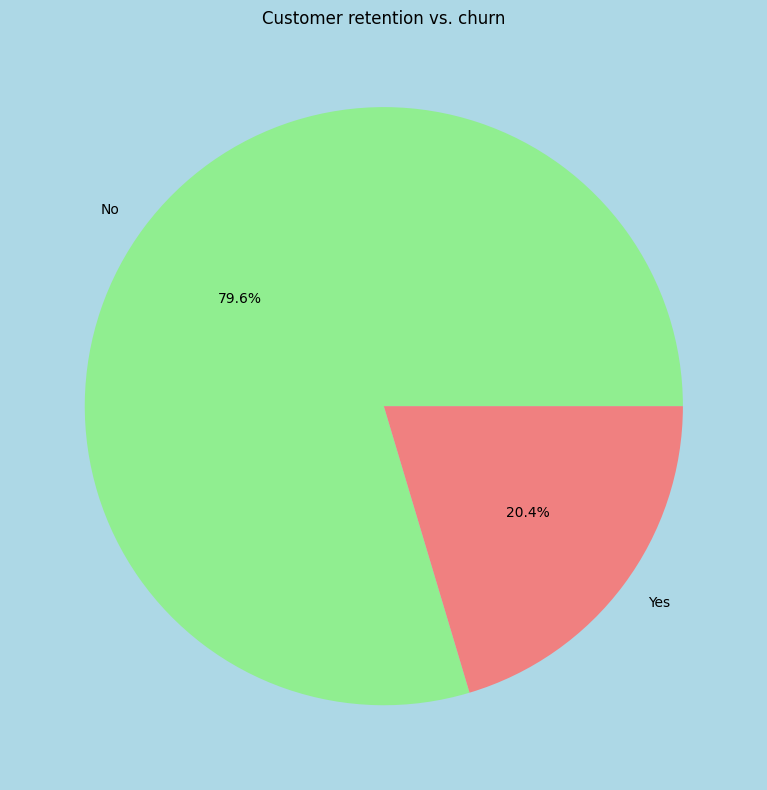

In [175]:
# grouping churn count
df_exit = churn_copy.groupby('Exited')['RowNumber'].count()

# Let's visualize the churn distribution using a pie chart for better understanding.
plt.figure(figsize=(12,8), facecolor='lightblue')
plt.pie(df_exit, labels=df_exit.index, autopct='%1.1f%%',  colors=['lightgreen', 'lightcoral'])
plt.title('Customer retention vs. churn')
plt.tight_layout()

##**🧐Insights:🔍**


📍 80% customer stayed and 20% cystomer churned.

## 2️⃣Churn Distribution Across Categorical Features:

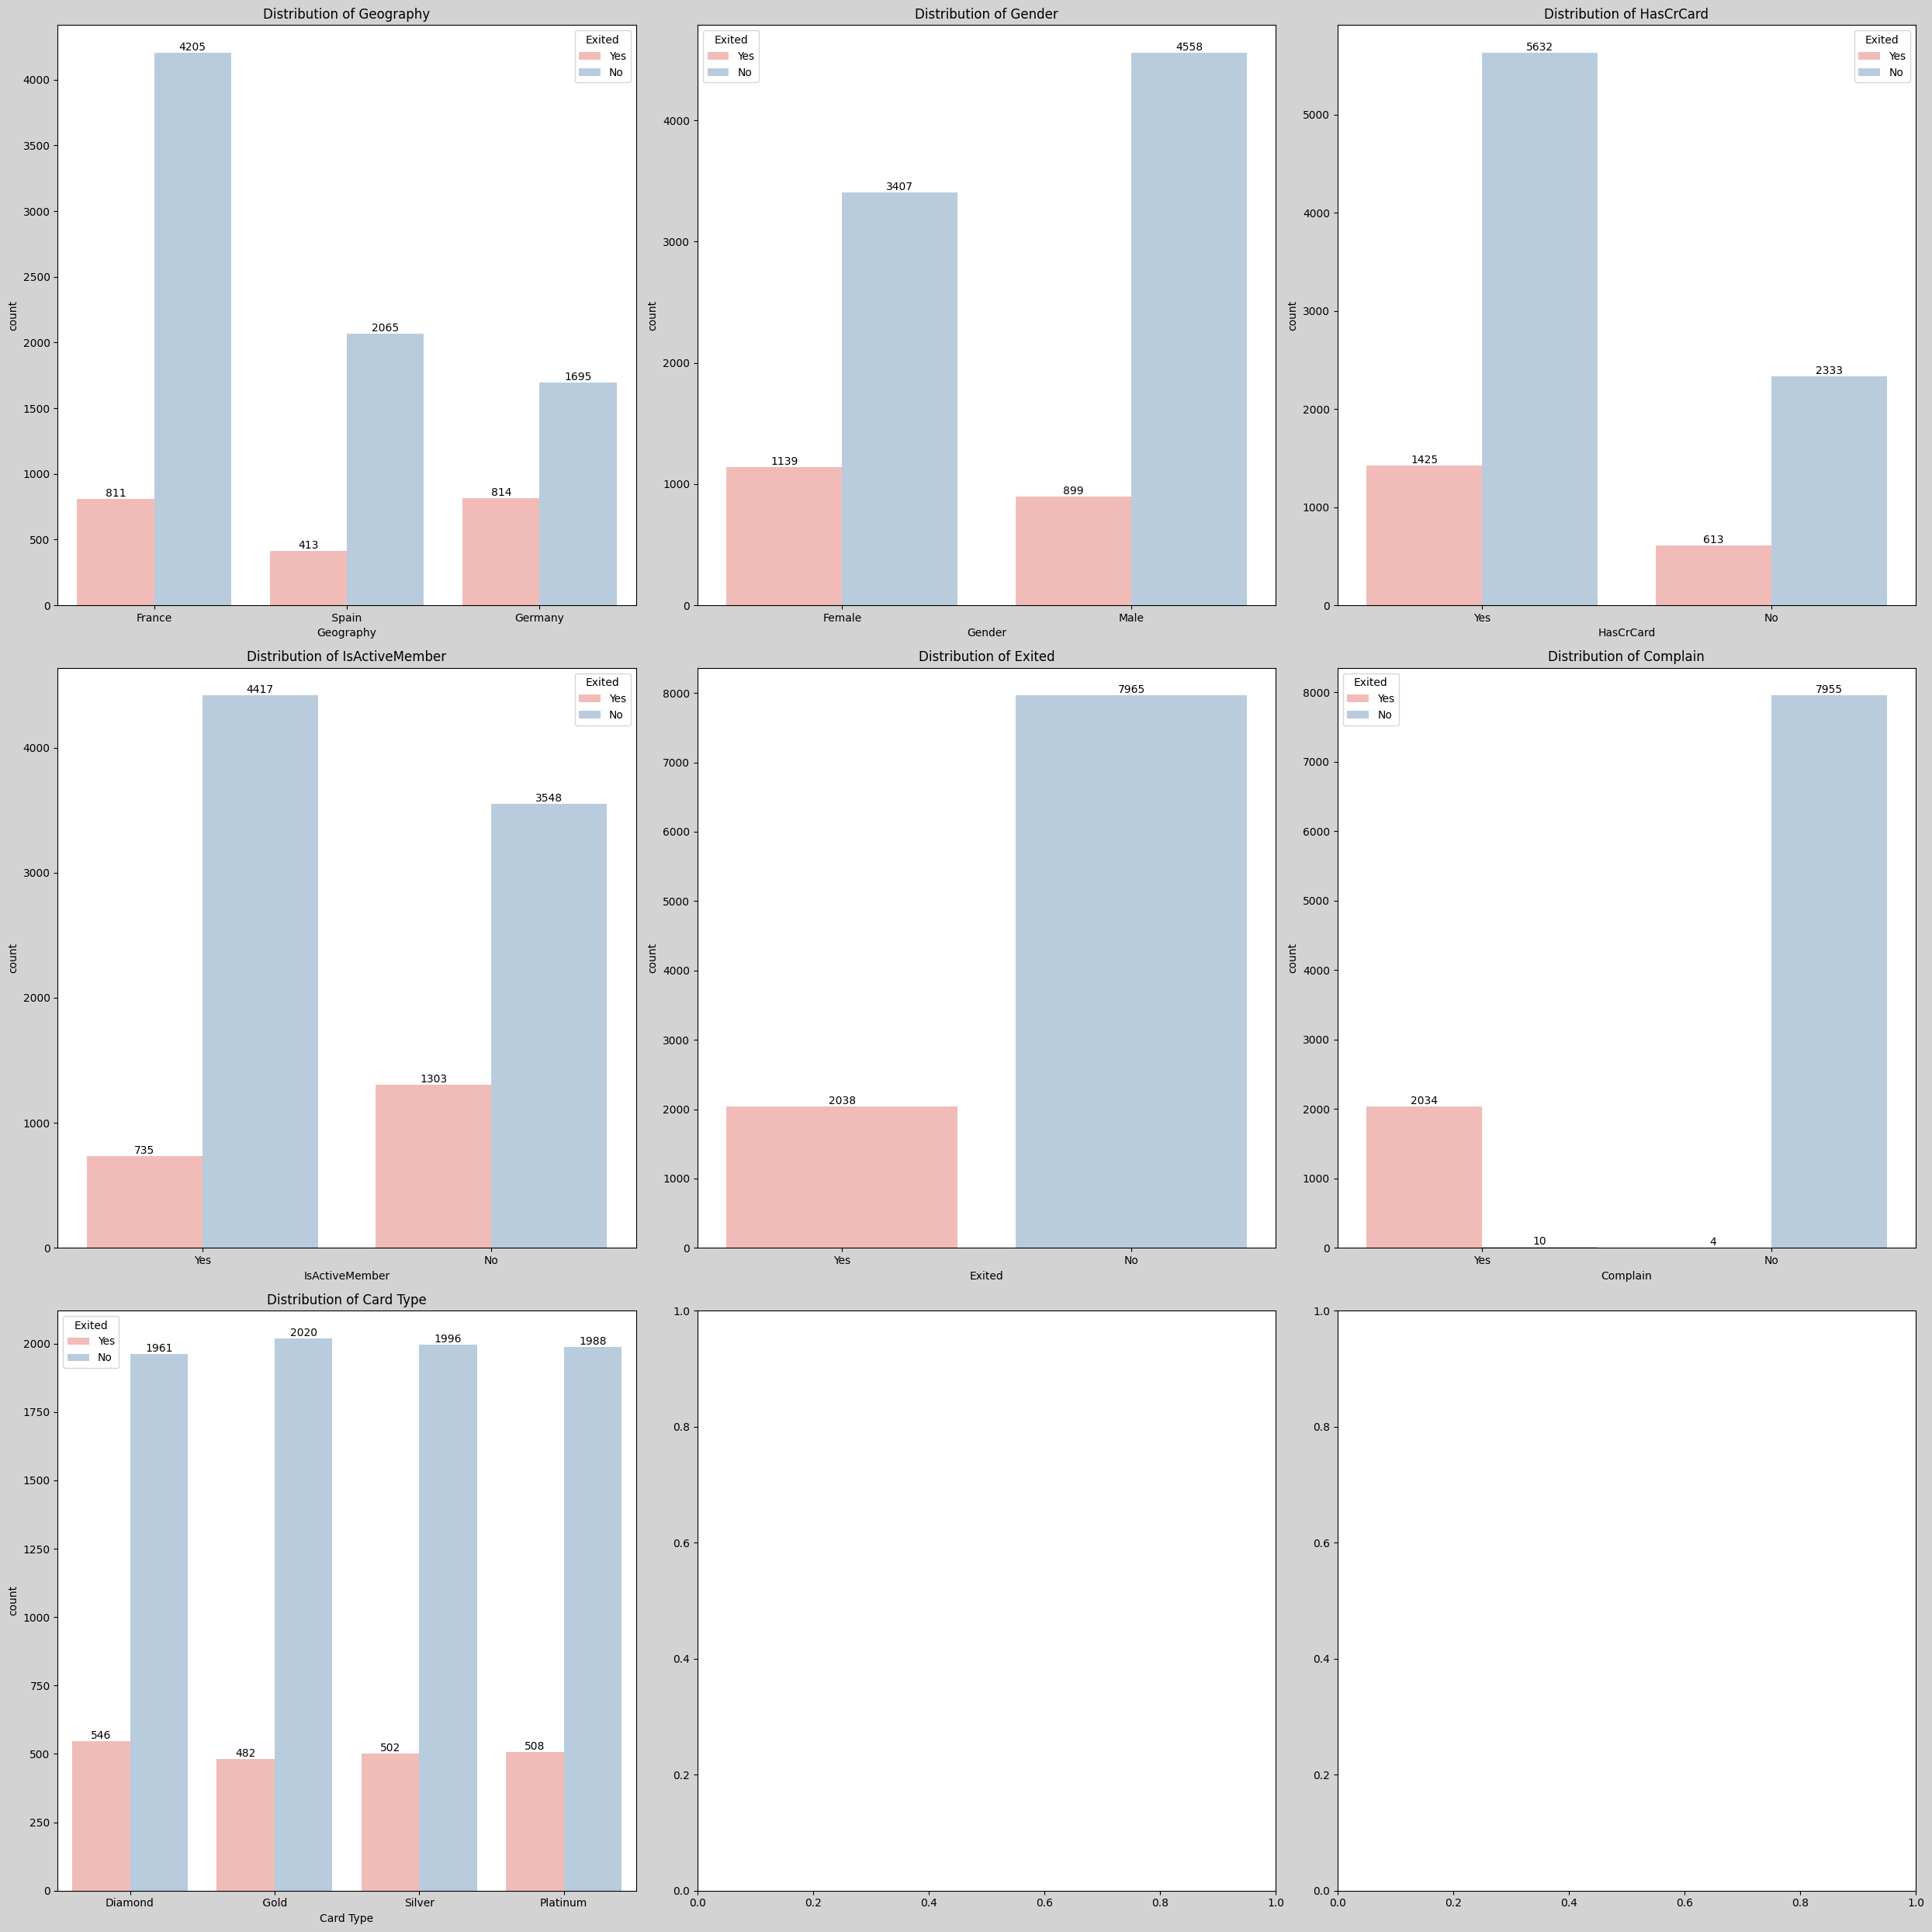

In [195]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(25, 25), facecolor='lightgray')
axes = axes.flatten()

for i, col in enumerate(categorical_features):
  sns.countplot(x=col, hue='Exited', palette='Pastel1', data=churn_copy, ax=axes[i]).set_title(f'Distribution of {col}')
  for container in axes[i].containers:
    axes[i].bar_label(container)

plt.tight_layout()
plt.show()

##**🧐Insights:🔍**

##🚩 Geography Distribution:

👉 France has the highest number of customers compared to other countries.

👉 Customers from France and Germany are more likely to churn.

##🚩 Gender Distribution:

👉 More males are in the dataset than females.

👉 Churn rate is higher for females than males.

##🚩 Has Credit Card:

👉 Most customers have a credit card.

👉 Having a credit card does not seem to strongly impact churn.

##🚩 Is Active Member:

👉 More inactive members are churning compared to active ones.

👉 Active members are more likely to stay with the bank.

##🚩 Complaints:

👉 Customers who raised complaints have a higher churn rate.

👉 Most customers did not raise complaints, but those who did are more likely to leave.

##🚩 Card Type vs Churn:

👉 All four card types have fairly balanced churn rates.

👉 Churn is slightly higher across all card types, but no major difference is observed between them.

##3️⃣ Boxplot for Active Members vs. Tenure

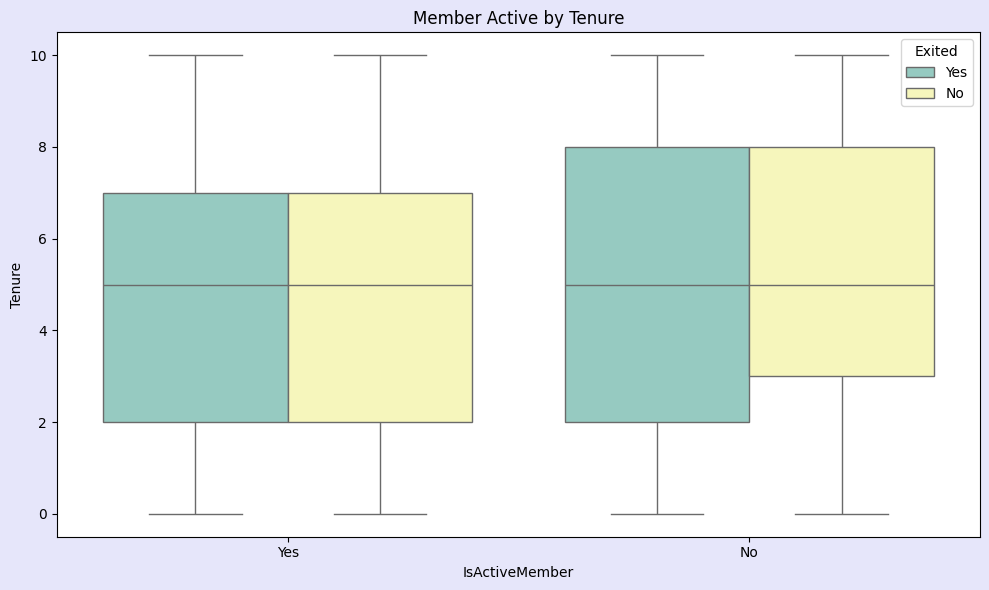

In [101]:
# Creating boxplot using seaborn
plt.figure(figsize=(10,6), facecolor='lavender')
sns.boxplot(churn_copy, x=churn_copy['IsActiveMember'], y=churn_copy['Tenure'], hue=churn_copy['Exited'], palette='Set3')
plt.title('Member Active by Tenure')
plt.tight_layout()
plt.show()

##**🧐Insights:🔍**

   📍 Non-active member have long tenure than active member and they are more likely to churn

##4️⃣ Age Distribution using Histogram

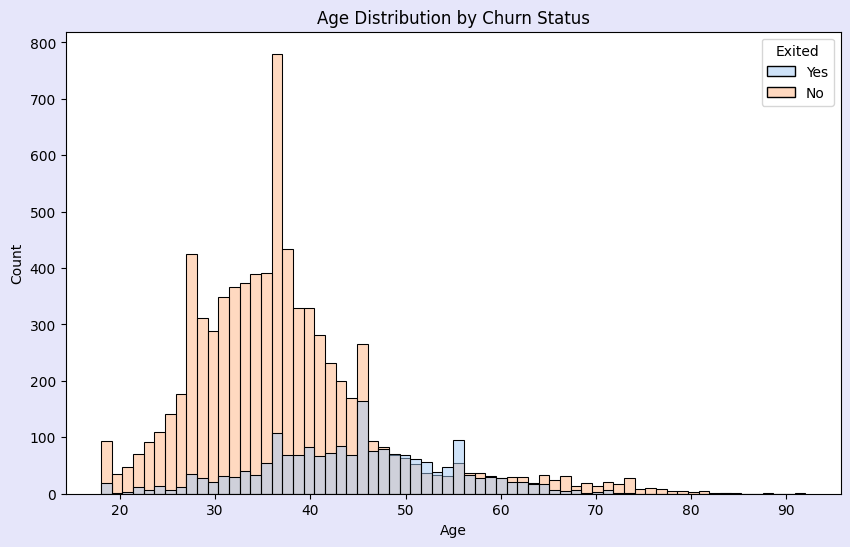

In [103]:
# filtering age since it has unrealistic outlier
age_filter = churn_copy[churn_copy['Age']<100]

plt.figure(figsize=(10,6), facecolor='lavender')
sns.histplot(data=age_filter, x=age_filter['Age'], hue=age_filter['Exited'], palette="pastel")
plt.title('Age Distribution by Churn Status')
plt.show()

##**🧐Insights:🔍**

📍  Older customers are more likely to churn.

In [105]:
churn_copy.columns

Index(['RowNumber', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score',
       'Card Type', 'Point Earned'],
      dtype='object')

## 5️⃣ Credit Score Distribution Analysis

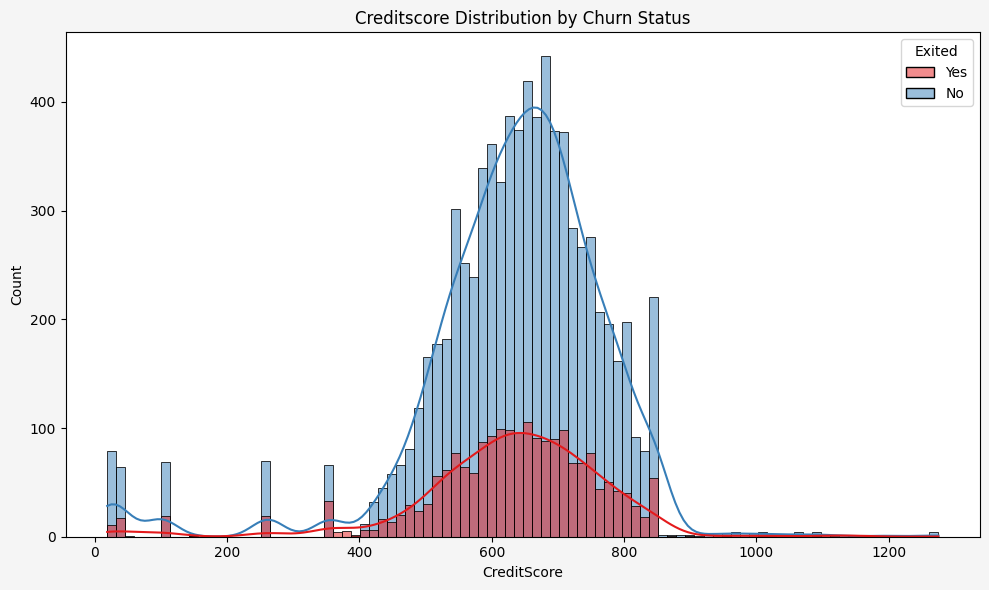

In [107]:
plt.figure(figsize=(10,6), facecolor='whitesmoke')
sns.histplot(data=churn_copy, x=churn_copy['CreditScore'], kde=True, hue=churn_copy['Exited'] , palette="Set1")
plt.title('Creditscore Distribution by Churn Status')
plt.tight_layout()
plt.show()

##**🧐Insights:🔍**

📍 members who have high creditscore are more likely to stay.

##6️⃣ Churn Rate by Estimatedsalary and Tenure Analysis using Histogram

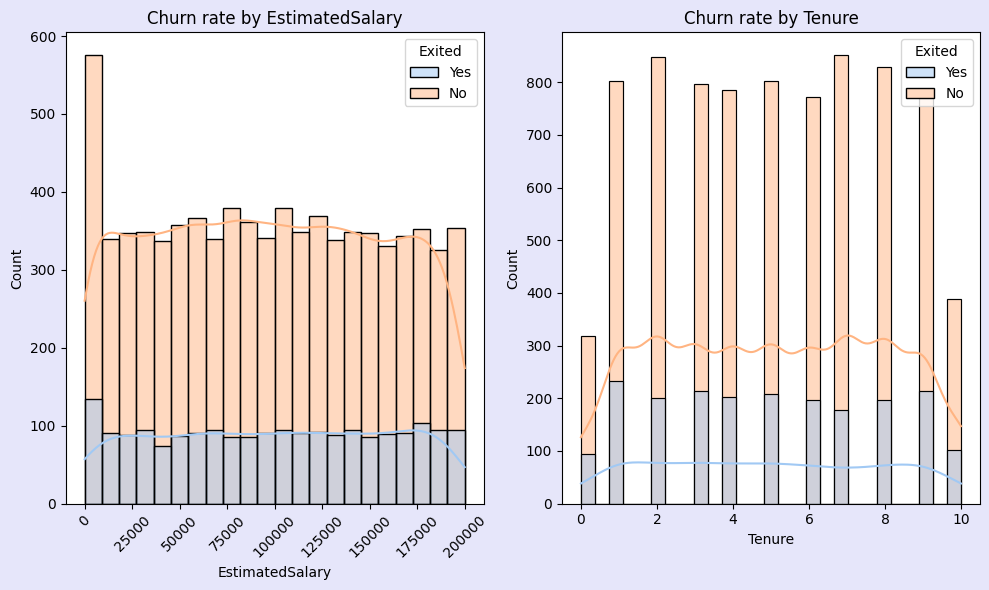

In [202]:
plt.figure(figsize=(10,6), facecolor='lavender')
plt.subplot(1,2,1)
sns.histplot(data=churn_copy, x=churn_copy['EstimatedSalary'], kde=True, hue=churn_copy['Exited'] , palette="pastel")
plt.xticks(rotation=45)
plt.title('Churn rate by EstimatedSalary')

plt.subplot(1,2,2)
sns.histplot(data=churn_copy, x=churn_copy['Tenure'], kde=True, hue=churn_copy['Exited'] , palette="pastel")
plt.title('Churn rate by Tenure')
plt.tight_layout()
plt.show()

In [109]:
churn_copy.columns

Index(['RowNumber', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score',
       'Card Type', 'Point Earned'],
      dtype='object')

##7️⃣ Complaint Analysis

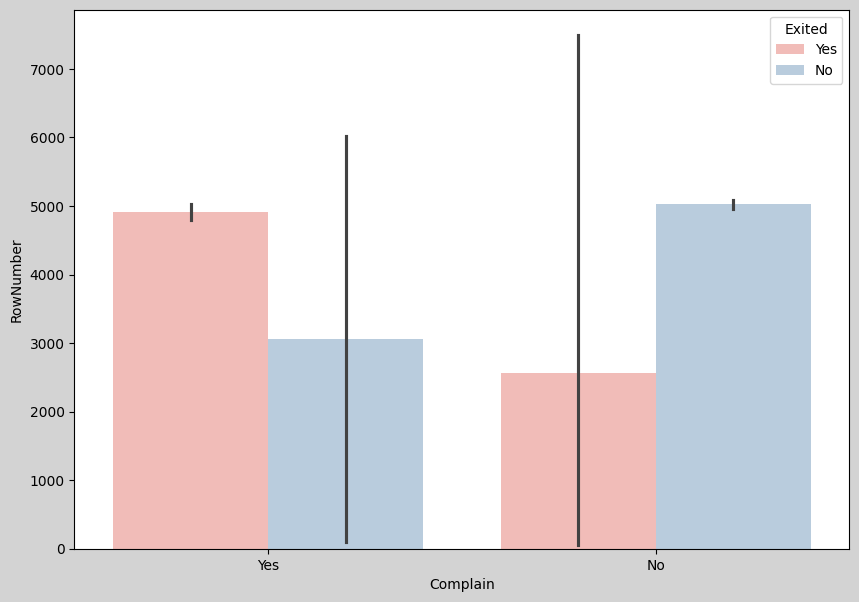

In [112]:
plt.figure(figsize=(10,7), facecolor='lightgray')
sns.barplot(data=churn_copy, x=churn_copy['Complain'], y=churn_copy['RowNumber'], hue=churn_copy['Exited'], palette="Pastel1")
plt.show()

##**🧐Insights:🔍**

 📍 Complained members are more likely to churn.

## 8️⃣🧩 Exploring Feature Relationships

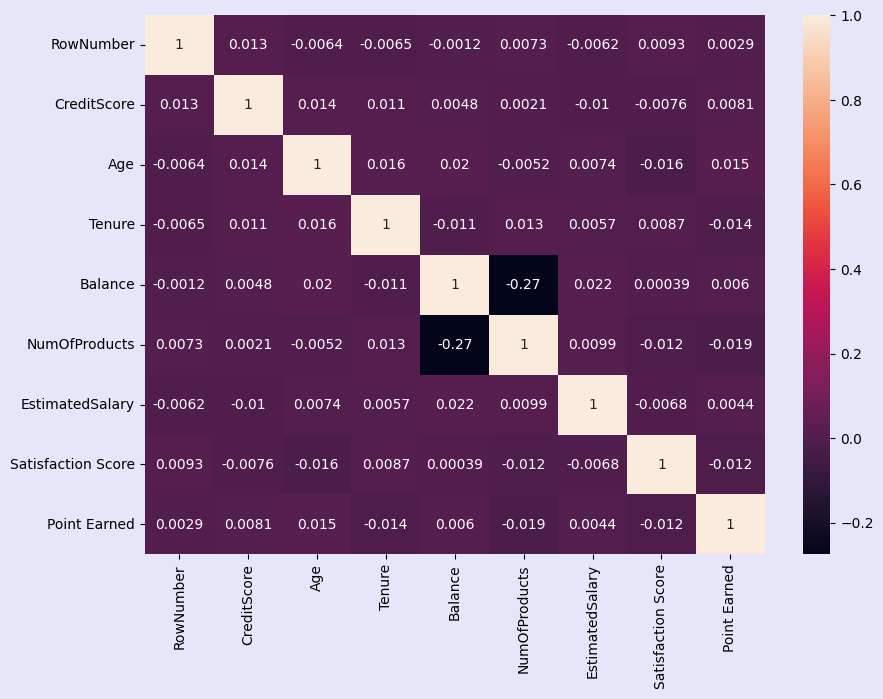

In [113]:
plt.figure(figsize=(10,7), facecolor='lavender')
sns.heatmap(churn_copy.select_dtypes(exclude='O').corr(), annot=True)
plt.show()

#✅ **Data Preprocessing**



---



##⭕**Handling missing values**

In [114]:
churn_copy.isnull().sum()

,0
RowNumber,0
CreditScore,80
Geography,0
Gender,0
Age,66
Tenure,0
Balance,97
NumOfProducts,0
HasCrCard,0
IsActiveMember,0


In [115]:
# Handling missing values
churn_copy['CreditScore'].fillna(churn_copy['CreditScore'].median(), inplace=True)
churn_copy['Age'].fillna(churn_copy['Age'].median(), inplace=True)
churn_copy['Age'] = churn_copy['Age'].astype(int) # converting into integer aswell to avoid over storage
churn_copy['Balance'].fillna(churn_copy['Balance'].median(), inplace=True)
churn_copy['EstimatedSalary'].fillna(churn_copy['EstimatedSalary'].median(), inplace=True)
churn_copy['Point Earned'].fillna(churn_copy['Point Earned'].median(), inplace=True)
churn_copy.isnull().sum()

,0
RowNumber,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0


##⭕ **Handling Outliers**

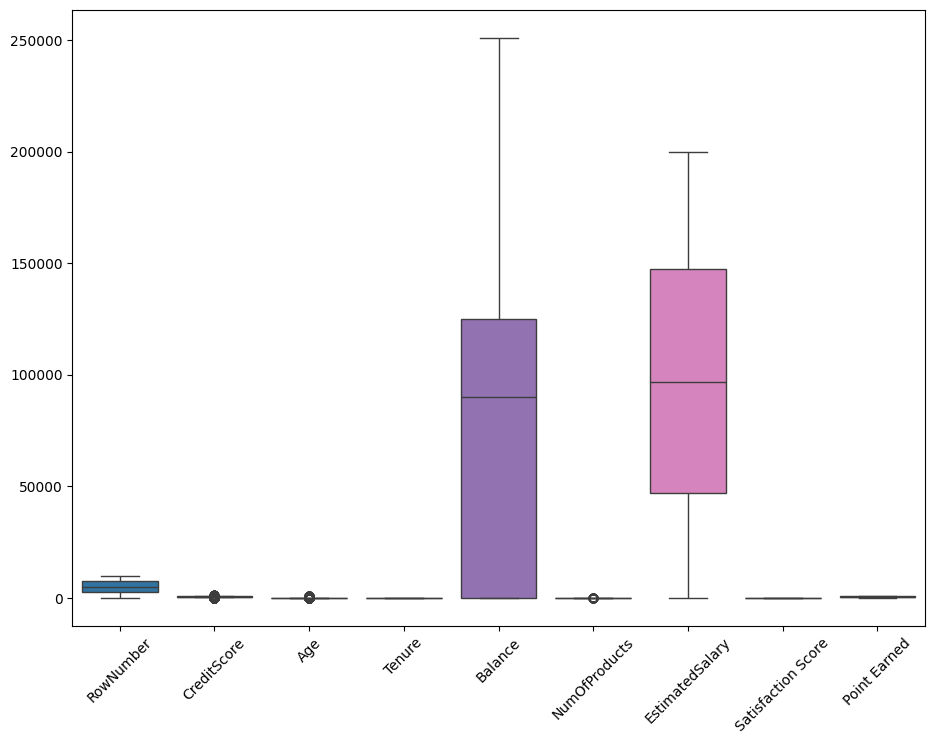

In [116]:
plt.figure(figsize=(11,8))
sns.boxplot(churn_copy)
plt.xticks(rotation=45)
plt.show()

In [117]:
Q1_cred = churn_copy['CreditScore'].quantile(0.25)
Q3_cred = churn_copy['CreditScore'].quantile(0.75)
IQR_cred = Q3_cred - Q1_cred
print(f"IQR: {IQR_cred}")

lowerbound_cred = Q1_cred - 1.5 * IQR_cred
upperbound_cred = Q3_cred + 1.5 * IQR_cred
print(f"Lowerbount: {lowerbound_cred}\nUpperbound: {upperbound_cred}")

churn_copy = churn_copy[(churn_copy['CreditScore']>=lowerbound_cred) & (churn_copy['CreditScore']<=upperbound_cred)]
churn_copy.shape

IQR: 145.0
Lowerbount: 354.5
Upperbound: 934.5


(9586, 16)

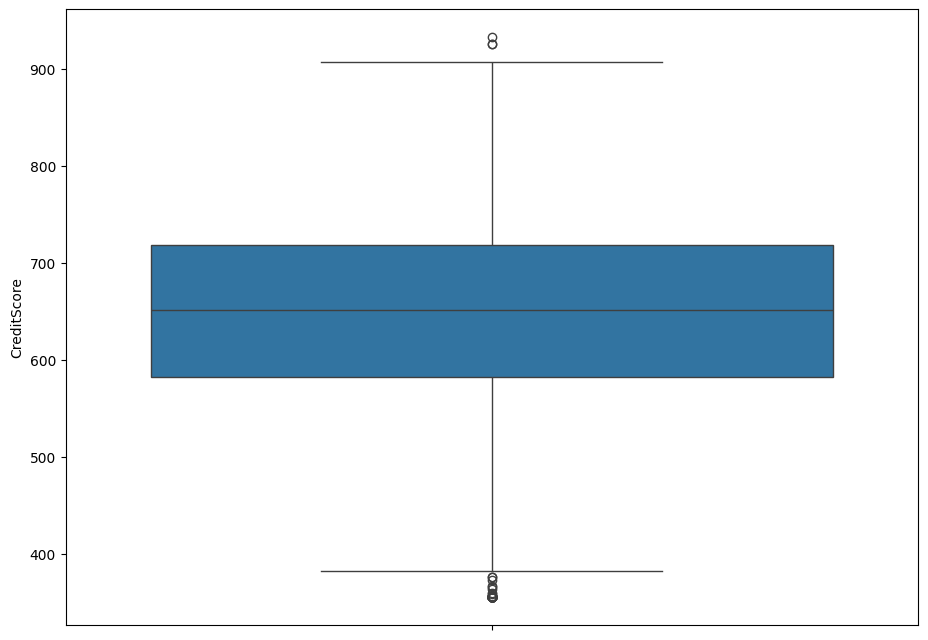

In [118]:
plt.figure(figsize=(11,8))
sns.boxplot(churn_copy['CreditScore'])
plt.xticks(rotation=45)
plt.show()

In [119]:
churn_copy['CreditScore'].skew()

np.float64(-0.20280578570656468)

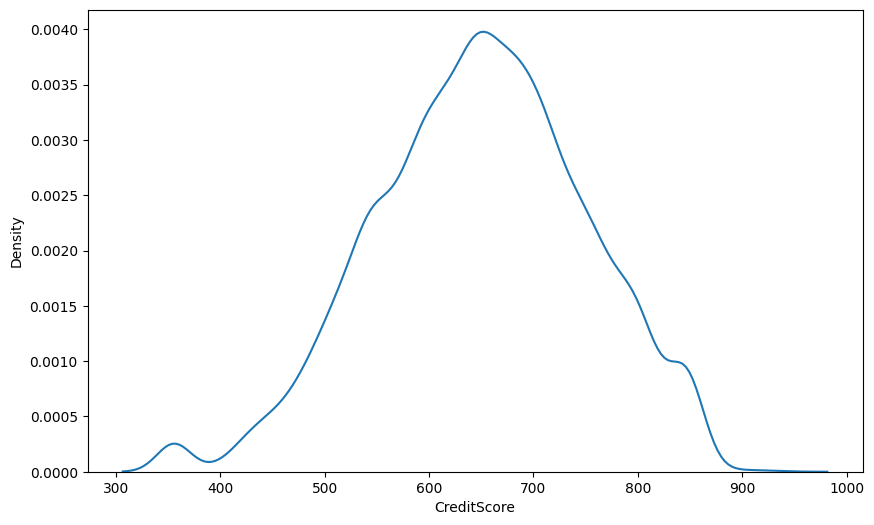

In [120]:
plt.figure(figsize=(10,6))
sns.kdeplot(churn_copy['CreditScore'])
plt.show()

In [121]:
Q1_age = churn_copy['Age'].quantile(0.25)
Q3_age = churn_copy['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
print(f"IQR: {IQR_age}")

lowerbound_age = Q1_age - 1.5 * IQR_age
upperbound_age  = Q3_age + 1.5 * IQR_age
print(f"Lowerbount: {lowerbound_age }\nUpperbound: {upperbound_age }")

churn_copy = churn_copy[(churn_copy['Age']>=lowerbound_age ) & (churn_copy['Age']<=upperbound_age )]
churn_copy.shape

IQR: 13.0
Lowerbount: 12.5
Upperbound: 64.5


(9014, 16)

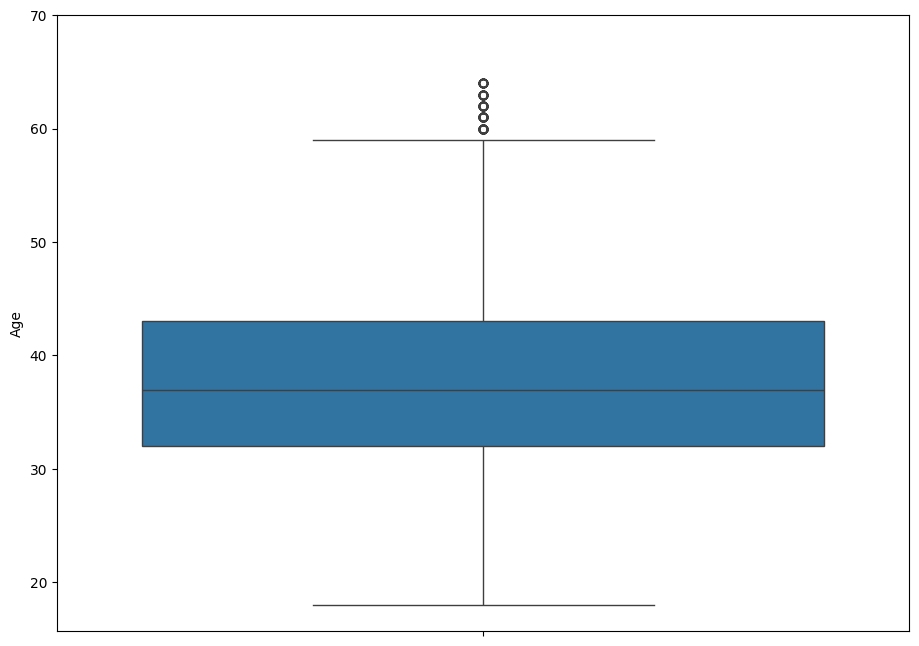

In [122]:
plt.figure(figsize=(11,8))
sns.boxplot(churn_copy['Age'])
plt.yticks(np.arange(20,75,10))
plt.xticks(rotation=45)
plt.show()

In [123]:
churn_copy['Age'].skew()

np.float64(0.5134555247532819)

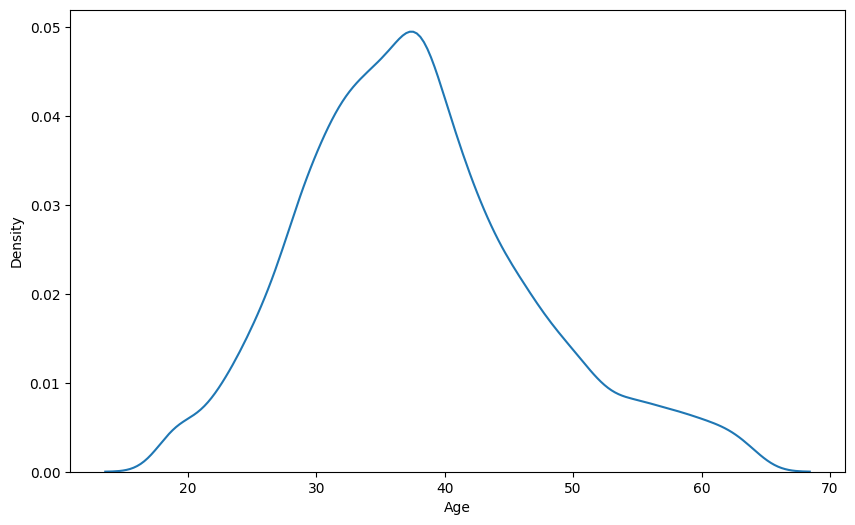

In [124]:
plt.figure(figsize=(10,6))
sns.kdeplot(churn_copy['Age'])
plt.show()

In [125]:
Q1_num = churn_copy['NumOfProducts'].quantile(0.25)
Q3_num = churn_copy['NumOfProducts'].quantile(0.75)
IQR_num = Q3_num - Q1_num
print(f"IQR: {IQR_num}")

lowerbound_num = Q1_num - 1.5 * IQR_num
upperbound_num  = Q3_num + 1.5 * IQR_num
print(f"Lowerbount: {lowerbound_num }\nUpperbound: {upperbound_num }")

churn_copy = churn_copy[(churn_copy['NumOfProducts']>=lowerbound_num ) & (churn_copy['NumOfProducts']<=upperbound_num)]
churn_copy.shape

IQR: 1.0
Lowerbount: -0.5
Upperbound: 3.5


(8961, 16)

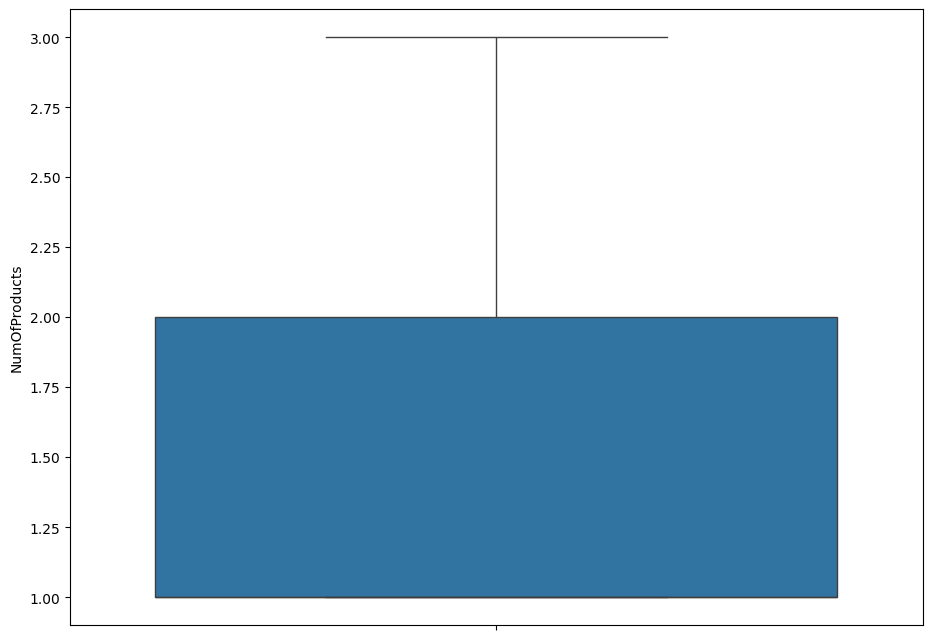

In [126]:
plt.figure(figsize=(11,8))
sns.boxplot(churn_copy['NumOfProducts'])
plt.xticks(rotation=45)
plt.show()

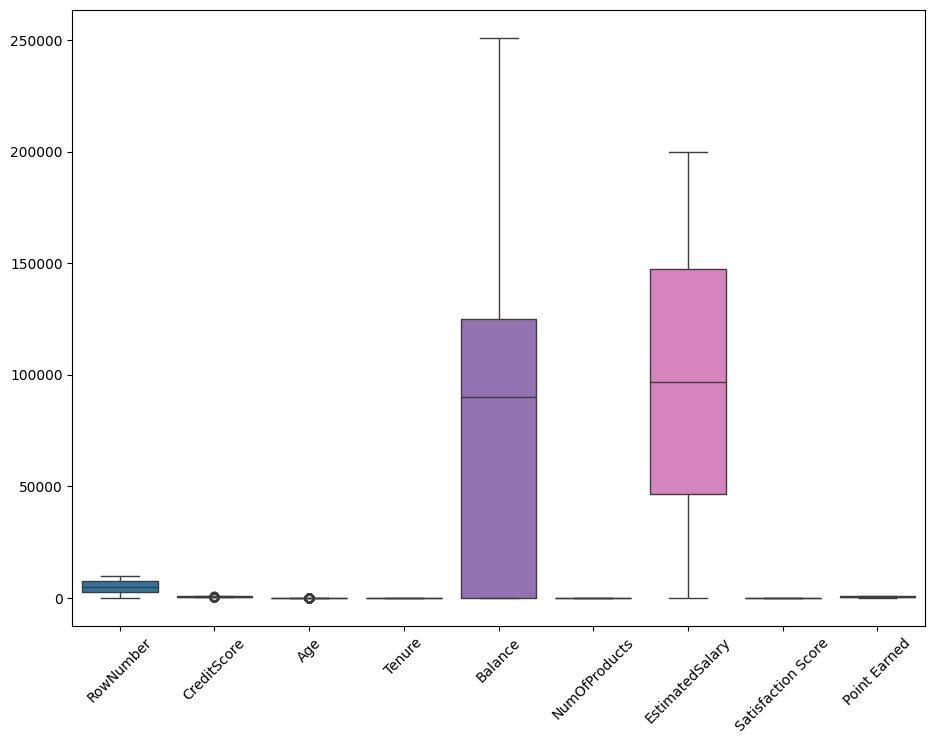

In [127]:
plt.figure(figsize=(11,8))
sns.boxplot(churn_copy)
plt.xticks(rotation=45)
plt.show()

#✅ **Feature Engineering**



---



##**⭕Feature Encoding**



---



In [128]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder() # object instantiation

# Label Encoding for all categorical features
for col in churn_copy.select_dtypes(include='object'):
  churn_copy[col] = label_encoder.fit_transform(churn_copy[col])

churn_copy

,RowNumber,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,619.0,1,0,42,2,0.00,1,1,1,101348.88,1,1,2,1,464
1,2,608.0,0,0,41,1,83807.86,1,0,1,112542.58,0,1,3,1,456
2,3,502.0,1,0,42,8,159660.80,3,1,0,113931.57,1,1,3,1,377
3,4,699.0,1,0,39,1,0.00,2,0,0,93826.63,0,0,5,0,350
4,5,850.0,0,0,43,2,125510.82,1,1,1,79084.10,0,0,5,0,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,771.0,1,1,39,5,0.00,2,1,0,96270.64,0,0,1,1,300
9996,9997,516.0,1,1,35,10,57369.61,1,1,1,101699.77,0,0,5,2,771
9998,9999,772.0,2,1,42,3,75075.31,2,1,0,92888.52,1,1,2,0,339
9999,10000,792.0,1,0,28,4,130142.79,1,1,0,38190.78,0,0,3,1,911


In [129]:
churn_copy['Exited'].value_counts() # target feature Yes = 0 and No = 1

,count
Exited,
0,7171
1,1790


##⭕ **Feature Selection**



---



In [130]:
# we will use SelectKBest to identify features, most, relevant to predicting the churn
from sklearn.feature_selection import SelectKBest, f_classif

X = churn_copy.drop(columns=['Exited']) # Features
y = churn_copy['Exited'] # Target

selector = SelectKBest(score_func=f_classif, k=7)
selected = selector.fit_transform(X, y)
X_selected = X.columns[selector.get_support()]
print("Selected Features:", X_selected)

Selected Features: Index(['Geography', 'Gender', 'Age', 'Balance', 'NumOfProducts',
       'IsActiveMember', 'Complain'],
      dtype='object')


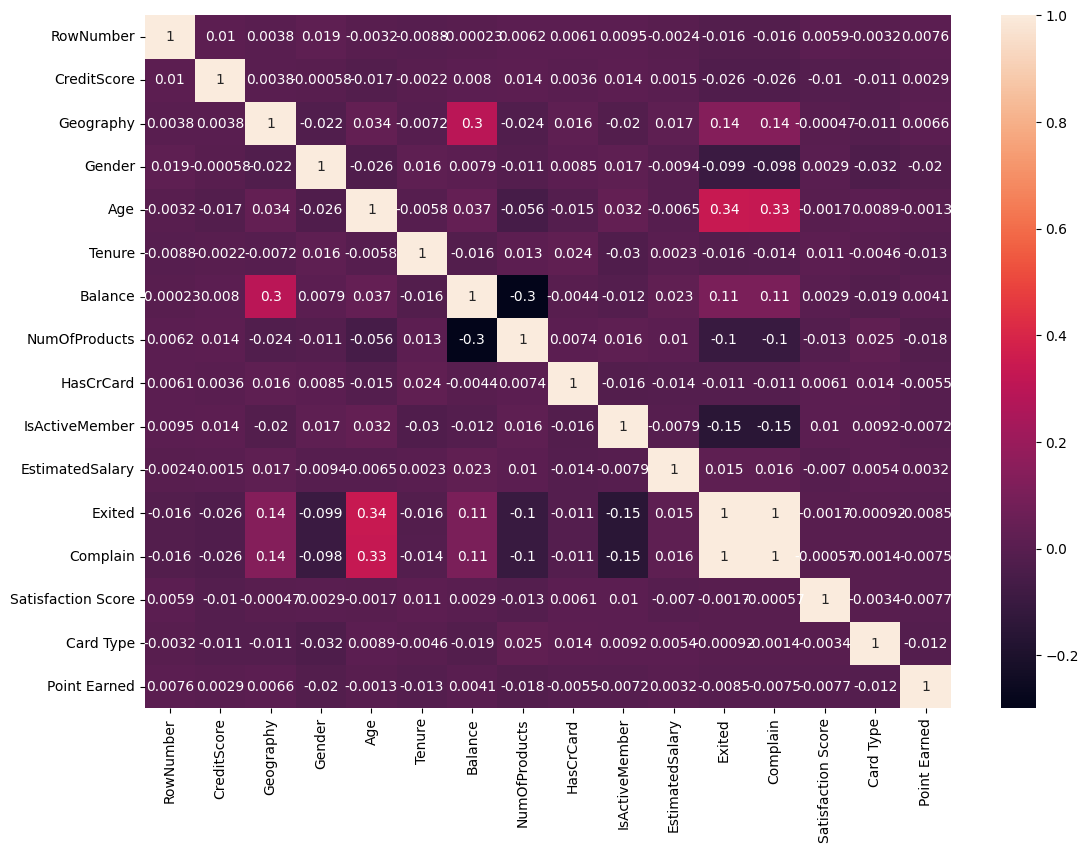

In [131]:
# vishualizing feature correlations using heatmap for better understanding
plt.figure(figsize=(13,9))
sns.heatmap(churn_copy.corr(), annot=True)
plt.show()

In [132]:
# checking correlation with target for feature selection
correlation = churn_copy.corr()
correlation['Exited'].sort_values(ascending=False)

,Exited
Exited,1.000000
Complain,0.995819
Age,0.335894
Geography,0.135184
Balance,0.105103
EstimatedSalary,0.015382
Card Type,-0.000923
Satisfaction Score,-0.001740
Point Earned,-0.008461
HasCrCard,-0.011423


##**🧐Insights:🔍**

📍 looks like complain column is extremely correlated with target column(exited) so i am not using that column because it gives the model an unfair advantage.

## ⭕ **Splitting the Dataset for Training and Testing**



---



In [133]:
from sklearn.model_selection import train_test_split

X = churn_copy[['Geography', 'Gender', 'Age', 'Balance', 'NumOfProducts', 'IsActiveMember']]# Features
y = churn_copy['Exited'] # Target

# Splitting the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45, stratify=y)

# check the split
print("Training Features:\n", X_train)
print("Testing Features:\n", X_test)

Training Features:
       Geography  Gender  Age    Balance  NumOfProducts  IsActiveMember
2395          1       1   52  170008.84              1               0
1811          1       0   26       0.00              2               1
1413          2       1   30     543.00              2               0
3649          1       1   41  153198.23              1               1
8203          0       1   33  116474.28              2               1
...         ...     ...  ...        ...            ...             ...
9364          1       0   49  119960.29              2               0
5953          0       0   31       0.00              1               0
36            0       1   31  145260.23              1               1
7266          0       0   60  168920.75              1               0
8899          1       0   41       0.00              2               1

[7168 rows x 6 columns]
Testing Features:
       Geography  Gender  Age    Balance  NumOfProducts  IsActiveMember
7965         

In [134]:
# checking train and test data shape
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (7168, 6)
X_test: (1793, 6)
y_train: (7168,)
y_test:  (1793,)


## **⭕ Feature Scaling**



---



In [135]:
from sklearn.preprocessing import StandardScaler

# seperating selected numeric features for scaling
num_features = [col for col in num_features if col in X_train.columns]

# Apply StandardScaler
scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])  #  training data
X_test[num_features] = scaler.transform(X_test[num_features])  #  test data

print("\nTraining Features:\n", X_train[num_features])
print("\nTesting Features:\n", X_test[num_features])


Training Features:
            Age   Balance  NumOfProducts
2395  1.554410  1.575272      -0.932835
1811 -1.305675 -1.132436       0.892598
1413 -0.865662 -1.123788       0.892598
3649  0.344374  1.307532      -0.932835
8203 -0.535652  0.722634       0.892598
...        ...       ...            ...
9364  1.224400  0.778155       0.892598
5953 -0.755658 -1.132436      -0.932835
36   -0.755658  1.181104      -0.932835
7266  2.434436  1.557942      -0.932835
8899  0.344374 -1.132436       0.892598

[7168 rows x 3 columns]

Testing Features:
            Age   Balance  NumOfProducts
7965  1.444406  0.852370       0.892598
8183  2.324432 -1.132436       0.892598
2863  0.564380 -1.132436       0.892598
9567 -0.975665 -1.132436      -0.932835
9542 -0.095639 -1.132436       0.892598
...        ...       ...            ...
527  -1.305675 -1.132436       0.892598
7701 -0.975665  0.247091      -0.932835
2727  2.104426  0.478326       0.892598
1511 -0.095639 -1.132436       0.892598
384   0.674384

#✅ **Model Building**

##⭕ **Using Logistic Regression Model**

In [136]:
from sklearn.linear_model import LogisticRegression
model1 = LogisticRegression(penalty='l2', C=0.1, class_weight='balanced', random_state=42)

# Train and predict
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)

# Evaluate the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
print('Accuracy Score:', accuracy_score(y_test, y_pred1))
print('f1_score:', f1_score(y_test, y_pred1))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred1))
print('Classification Report:\n', classification_report(y_test, y_pred1))

Accuracy Score: 0.7272727272727273
f1_score: 0.5075528700906344
Confusion Matrix:
 [[1052  383]
 [ 106  252]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.73      0.81      1435
           1       0.40      0.70      0.51       358

    accuracy                           0.73      1793
   macro avg       0.65      0.72      0.66      1793
weighted avg       0.81      0.73      0.75      1793



##⭕ **Using KNeighbors Classifier Model**

In [137]:
from sklearn.neighbors import KNeighborsClassifier
model2 = KNeighborsClassifier()

# Train and predict
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

# Evaluate the model
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

print('Accuracy score:', accuracy_score(y_test, y_pred2))
print('f1_score:', f1_score(y_test, y_pred2))
print('cofusion matrix:\n', confusion_matrix(y_test, y_pred2))
print('classification Report:\n', classification_report(y_test, y_pred2))

Accuracy score: 0.8477412158393753
f1_score: 0.5673534072900158
cofusion matrix:
 [[1341   94]
 [ 179  179]]
classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.91      1435
           1       0.66      0.50      0.57       358

    accuracy                           0.85      1793
   macro avg       0.77      0.72      0.74      1793
weighted avg       0.84      0.85      0.84      1793



##⭕ **Using DecisionTree Classifier Model**

In [138]:
from sklearn.tree import DecisionTreeClassifier
model3 = DecisionTreeClassifier()

# Train and predict
model3.fit(X_train, y_train)
y_pred3 = model3.predict(X_test)

# Evaluate the model
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

print('Accuracy score:', accuracy_score(y_test, y_pred3))
print('f1_score:', f1_score(y_test, y_pred3))
print('confusion matrix:\n', confusion_matrix(y_test, y_pred3))
print('classification report:\n', classification_report(y_test, y_pred3))

Accuracy score: 0.8008923591745678
f1_score: 0.4992987377279102
confusion matrix:
 [[1258  177]
 [ 180  178]]
classification report:
               precision    recall  f1-score   support

           0       0.87      0.88      0.88      1435
           1       0.50      0.50      0.50       358

    accuracy                           0.80      1793
   macro avg       0.69      0.69      0.69      1793
weighted avg       0.80      0.80      0.80      1793



##⭕ **Using RandomForest Classifier Model**

In [139]:
from sklearn.ensemble import RandomForestClassifier
model4 = RandomForestClassifier()

# Train and predict
model4.fit(X_train, y_train)
y_pred4 = model4.predict(X_test)

# Evaluate the model
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

print('Accuracy score:', accuracy_score(y_test, y_pred4))
print('f1_score:', f1_score(y_test, y_pred4))
print('confusion matrix:\n', confusion_matrix(y_test, y_pred4))
print('classification report:\n', classification_report(y_test, y_pred4))

Accuracy score: 0.8399330730619075
f1_score: 0.5564142194744977
confusion matrix:
 [[1326  109]
 [ 178  180]]
classification report:
               precision    recall  f1-score   support

           0       0.88      0.92      0.90      1435
           1       0.62      0.50      0.56       358

    accuracy                           0.84      1793
   macro avg       0.75      0.71      0.73      1793
weighted avg       0.83      0.84      0.83      1793



##⭕ **Using Support Vector Classification(SVC) Model**

In [140]:
from sklearn.svm import SVC
model5 = SVC()

# Train and predict
model5.fit(X_train, y_train)
y_pred5 = model5.predict(X_test)

# Evaluate the model
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

print('Accuracy score:', accuracy_score(y_test, y_pred5))
print('f1 score:', f1_score(y_test, y_pred5))
print('confusion matrix:\n', confusion_matrix(y_test, y_pred5))
print('classification report:\n', classification_report(y_test, y_pred5))

Accuracy score: 0.8616843279419967
f1 score: 0.5175097276264592
confusion matrix:
 [[1412   23]
 [ 225  133]]
classification report:
               precision    recall  f1-score   support

           0       0.86      0.98      0.92      1435
           1       0.85      0.37      0.52       358

    accuracy                           0.86      1793
   macro avg       0.86      0.68      0.72      1793
weighted avg       0.86      0.86      0.84      1793



##⭕ **Using GaussianNB Model**

In [141]:
from sklearn.naive_bayes import GaussianNB
model6 = GaussianNB()

# Train and predict
model6.fit(X_train, y_train)
y_pred6 = model6.predict(X_test)

# Evaluate the model
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

print('Accuracy score:', accuracy_score(y_test, y_pred6))
print('f1 score:', f1_score(y_test, y_pred6))
print('confusion matrix:\n', confusion_matrix(y_test, y_pred6))
print('classification_report:\n', classification_report(y_test, y_pred6))

Accuracy score: 0.8276631344116007
f1 score: 0.4091778202676864
confusion matrix:
 [[1377   58]
 [ 251  107]]
classification_report:
               precision    recall  f1-score   support

           0       0.85      0.96      0.90      1435
           1       0.65      0.30      0.41       358

    accuracy                           0.83      1793
   macro avg       0.75      0.63      0.65      1793
weighted avg       0.81      0.83      0.80      1793



##⭕ **Using XGB Classifier Model**



In [142]:
from xgboost import XGBClassifier
model7 = XGBClassifier()

# Train and predict
model7.fit(X_train, y_train)
y_pred7 = model7.predict(X_test)

# Evaluate the model
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

print('Accuracy score:', accuracy_score(y_test, y_pred7))
print('f1 score:', f1_score(y_test, y_pred7))
print('confusion matrix:\n', confusion_matrix(y_test, y_pred7))
print('classification_report:\n', classification_report(y_test, y_pred7))

Accuracy score: 0.8600111544896821
f1 score: 0.5767284991568297
confusion matrix:
 [[1371   64]
 [ 187  171]]
classification_report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      1435
           1       0.73      0.48      0.58       358

    accuracy                           0.86      1793
   macro avg       0.80      0.72      0.75      1793
weighted avg       0.85      0.86      0.85      1793



#✅ **Model Evaluation and Comparison**

In [143]:
# Dictionary of classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=43),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Support Vector Classifier': SVC(),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier()
}

In [144]:
# Initialize an empty dictionary to score the results
results ={}

# Iterate througah classifiers
for name, clf in classifiers.items():
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)
  # calculate metrics
  accuracy = accuracy_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred, average='binary')
  # store the results
  results[name] = {'accuracy':accuracy, 'F1 score': f1}

# Convert the  results dictionary to a DataFrame
results_df = pd.DataFrame(results).T
results_df

,accuracy,F1 score
Logistic Regression,0.726715,0.507042
K-Nearest Neighbors,0.847741,0.567353
Decision Tree,0.804239,0.500711
Random Forest,0.839933,0.550861
Support Vector Classifier,0.861684,0.517510
Naive Bayes,0.827663,0.409178
XGBoost,0.860011,0.576728


##**Insights:**  XGBoost is the best performer overall with the highest accuracy (0.860011) and a competitive F1 score (0.5767).

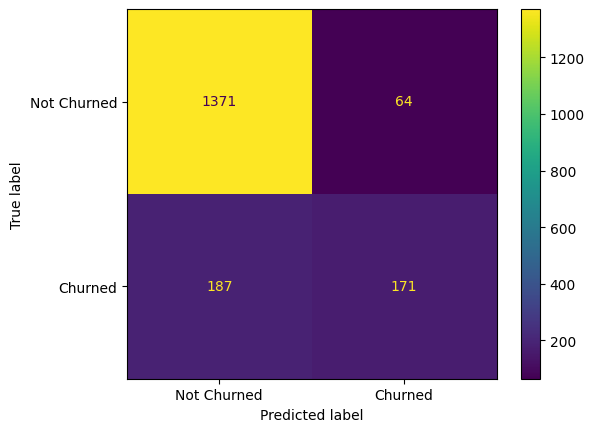

In [145]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model7, X_test, y_test, display_labels=['Not Churned', 'Churned'])
plt.show()

#⭕ StratifiedKFold Cross-Validation

In [146]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# K-fold cross-validation
k= 5 # no of folds
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=18)

# print the header
print(f"{'classifier':<25} {'mean accuracy':<20} {'mean F1 score':<20}")

# Iterate through classifiers and perform cross-validation
for name, clf in classifiers.items():
  accuracy_scores = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')
  f1_score = cross_val_score(clf, X, y, cv=skf, scoring='f1_weighted')
  print(f"{name:<25} {accuracy_scores.mean():<20.4f} {f1_score.mean():<20.4f}")

classifier                mean accuracy        mean F1 score       
Logistic Regression       0.6741               0.7056              
K-Nearest Neighbors       0.7802               0.7441              
Decision Tree             0.8029               0.8032              
Random Forest             0.8421               0.8325              
Support Vector Classifier 0.8002               0.7115              
Naive Bayes               0.8016               0.7607              
XGBoost                   0.8497               0.8387              


##**📌Insights**: Even using Cross-validation from overall comparison still XGBoost model performs well.

#⭕ROC Curve and AUC

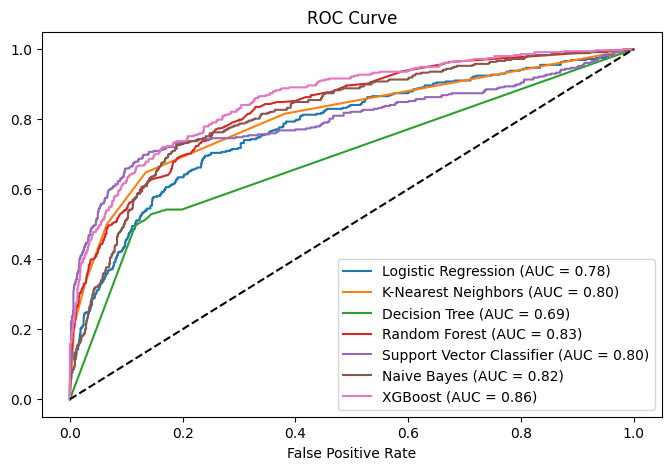

In [151]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,5))

for name,clf in classifiers.items():
  clf.fit(X_train, y_train)
  y_probs = clf.predict_proba(X_test)[:,1] if hasattr(clf, "predict_proba") else clf.decision_function(X_test)
  fpr, tpr, _ = roc_curve(y_test, y_probs)
  plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.legend(loc='lower right')
plt.show()

##**📌Insights:**  Visualizing the results clearly shows that the XGBoost model performs the best.

#**✅Final Conclusion:**

##**🎯 Objective: 🏦🔍**
This project aimed to identify the key factors influencing customer churn using demographic and financial data. Providing valuable insights for customer retention strategies.

##**📌 Methodology 🔬📊**
- We fixed misspelling, missing values, and inconsistencies in the data using  appropriate techniques (e.g., filling missing values, standardizing text formats).  
- Encoded categorical features using **label encoding**.  
- Scaled numerical features using **StandardScaler** for better model performance.  to improve quality.   
- Through effective feature selection techniques, we pinpointed the most significant variables contributing to churn, enhancing predictive accuracy and providing valuable insights for customer retention strategies.

##**🏆Finding the Best Performing model:🥇✨**

 - Trained multiple models: **Logistic Regression, Decision tree, KNeighbor classifier, Naive Bayes, Random Forest, XGBoost, and SVM**.  
 - Compared models using **accuracy, precision, recall, F1-score, and AUC-ROC curve**.  
 - Identified **XGBoost as the best-performing model** with the highest AUC. The ROC curve analysis further supports the findings from the initial evaluation, indicating that the XGBoost model achieves the highest AUC among the tested classifiers.
 - This reinforces the conclusion that XGBoost is particularly effective for this dataset, offering superior performance in distinguishing between classes and addresssing class imbalance.

##**🚧 Challenges faced and solution:⚠️🔄**

1. challenge was dealing with imbalanced data, which caused biased predictions.

  **Solution:** We fixed this by removing the 'complain' feature because it was too closely related to the target and affected the results.

2. Initially, models showed moderate F1-scores around(40-55%), making it difficult to determine the best one. Accuracy alone was misleading because some models had high accuracy but lower F1-scores.

 **Solution:** Applied K-Fold Cross-Validation to get a more reliable performance estimate.After K-Fold, XGBoost had the highest F1-score (0.8387) and strong accuracy (0.8497), confirming it as the best model.
Random Forest also performed well, but XGBoost showed a slight edge in both accuracy and F1-score.

##**🔑 Key Takeaways ✅📌**
- Customer churn is influenced by multiple factors such as Age, Geography, Balance, Gender, Number of Products, and Active Membership Status.
- XGBoost performed the best among all models but may require further fine-tuning for optimization.
- Feature selection played a crucial role, improving model accuracy by focusing on the most relevant variables.

# ✅ 💡Recommendations:🏦

1️⃣ Personalized Banking Offers 🎯
Use customer data (age, balance, product usage) to offer customized interest rates, credit card upgrades, or lower fees.

Example: A high-balance customer might get higher interest rates on savings to encourage retention.

2️⃣ Loyalty & Rewards Programs 🎁
Provide exclusive benefits for long-term customers, such as cashback, bonus points, or VIP services.

Example: Customers who stay for 3+ years receive free premium banking services.

3️⃣ Proactive Engagement & Support 📞
Identify inactive or low-engagement customers (e.g., low transactions, rare logins) and reach out with offers, surveys, or special assistance.

Example: A customer who hasn’t used their account for months receives a personalized discount or call from a banking rep.

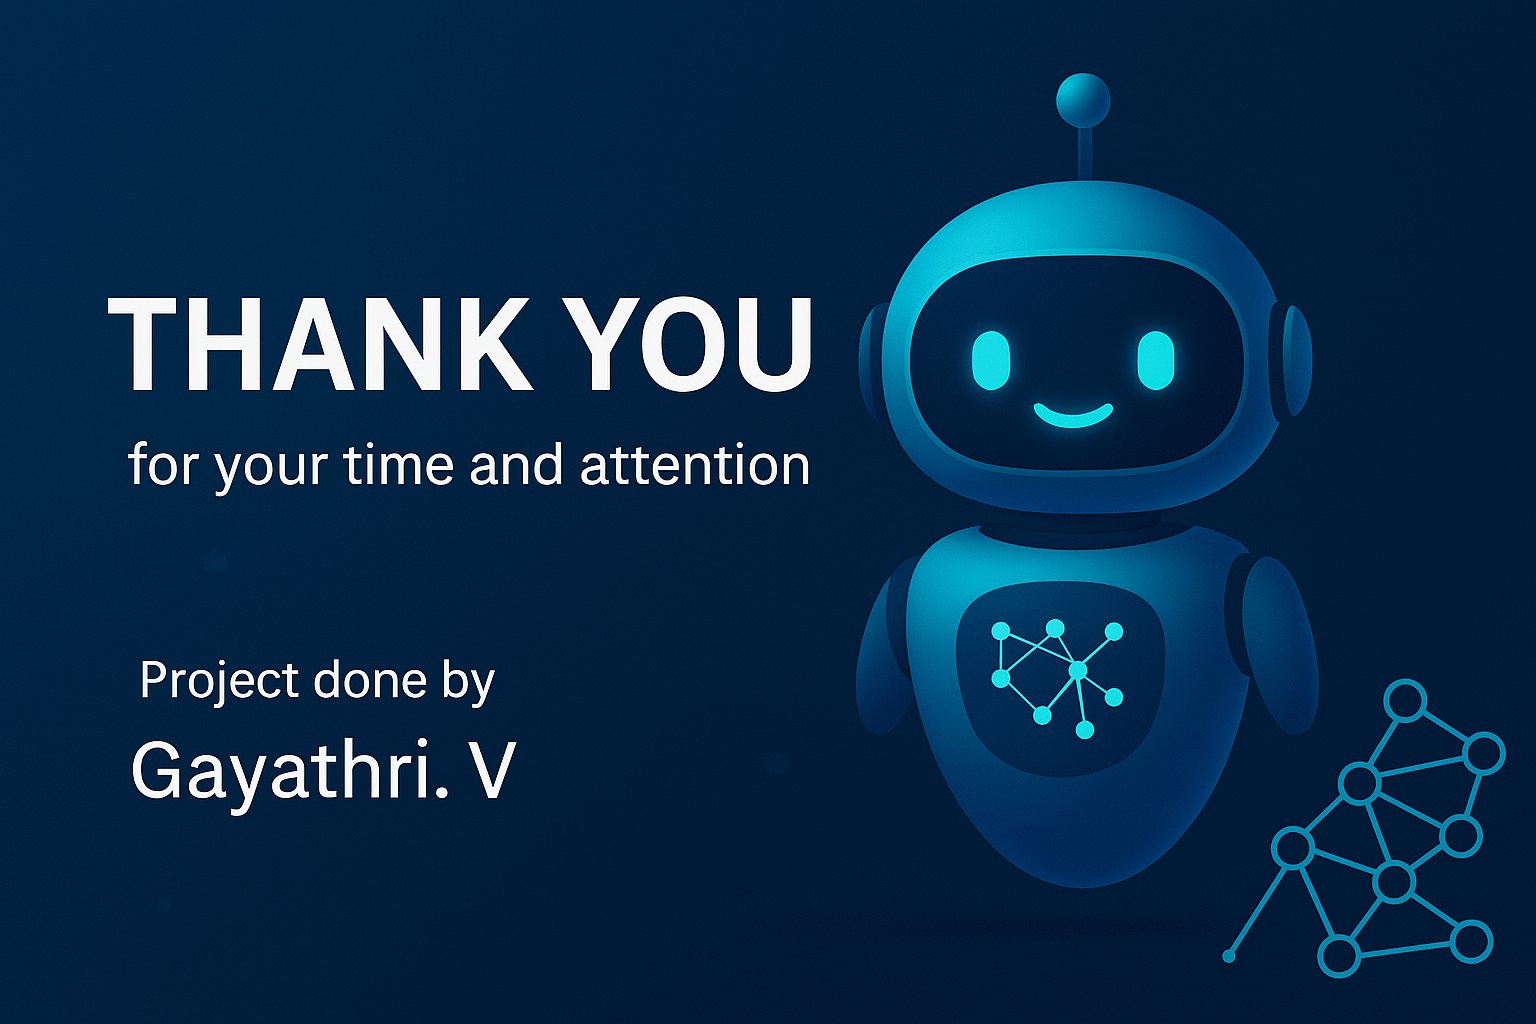